It can be shown that what we want to calculate is: 

$$\delta (O) = -2v \sum_n \frac{\braket{0|\hat O |n}\braket{n|\partial_\lambda H |0}+\braket{0|\partial_\lambda H|n}\braket{n|\hat O |0} }{2(E_n-E_0)^2}$$

We know that

$$\braket{0|\sum_j \sigma_x^i \sigma_x^{i+1}|k,-k}= L (-cos(k)-isin(\theta_k-k))$$

$$\braket{0|\sum_j \sigma_z^i|k,-k}= L isin(\theta_k)$$


$$\Delta_{k,0}= E_{k,-k}-E_0 = 2\sqrt{1+g^2-2g\cos(k)}$$

In [333]:
import sys 

sys.path.append("../../src")

from common_imports import *



In [337]:
def theta_k(k,g):
    return np.arctan2(sin(k),(g-cos(k)))

# def xx(k,g):
#     t = theta_k(g,k)
#     return -cos(k)+1j*sin(k-t)
def xx(k, g):
    t = theta_k(k, g)    # your θ_k(g)
    return np.cos(k)*np.sin(t) - 1j*np.sin(k)*np.cos(t)

def z(k,g):
    t = theta_k(g,k)
    return 1j*sin(t)

def delta(k,g):
    return 2*sqrt(1+g*g-2*g*cos(k))

def delta_O(k,g,v):
    t = theta_k(k,g)
    XX = xx(k,g)
    Z = z(k,g)
    D = delta(k,g)
    num = XX*Z+np.conjugate(XX*Z)
    return -2*v*np.sum(num/(2*D*D))


$$b(\lambda(t)) = \int d\lambda' e^{i/v \int_{\lambda^*}^{\lambda'} E_m(\lambda'')-E_0(\lambda'') d\lambda''} \braket{k,-k(\lambda)|d\lambda'|0(\lambda')}$$

100%|██████████| 100/100 [00:02<00:00, 41.27it/s]


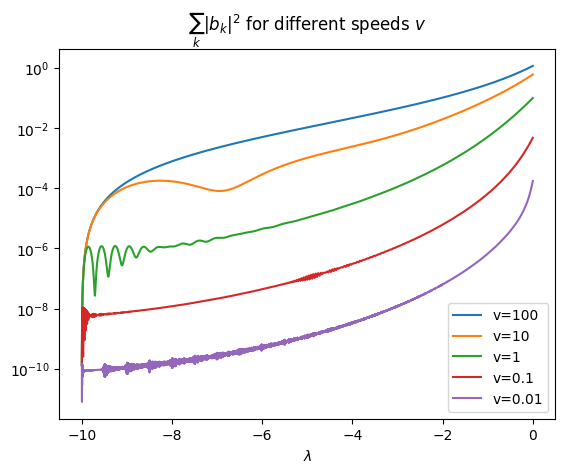

In [473]:
def b_k(lambda_0,lambda_f,N_steps,k,v):
    lambdas ,dl = linspace(lambda_0,lambda_f,N_steps,retstep=True)

    gaps = array([delta(k,1-l) for l in lambdas])
    phases = np.exp(np.cumsum(gaps*dl)*1j/v)

    agp_matrix_element = array([1j*sin(theta_k(k,1-l))/(delta(k,l-1)) for l in lambdas])
    return np.cumsum(agp_matrix_element*phases*dl)
l0 = -10
lf = 0.000001
N = 10000
vs = [100,10,1,.1,.01,]
k= np.linspace(-pi,pi,100)
lambdas ,dl = linspace(l0,lf,N,retstep=True)

x=[]
for v in vs:
    
    y= sum([ np.abs(b_k(l0,lf,N,ki,v))**2 for ki in tqdm(k)])/2/pi
    x.append(y)
    plot(lambdas,y,label=f"v={v}")

legend()
title(r"$\sum_k |b_k|^2$ for different speeds $v$")
xlabel(r"$\lambda$")
yscale("log")


In [ ]:
def b_k_s(k,l):
    g= 1-l
    return z(k,g)/2/(delta(k,g)**2)


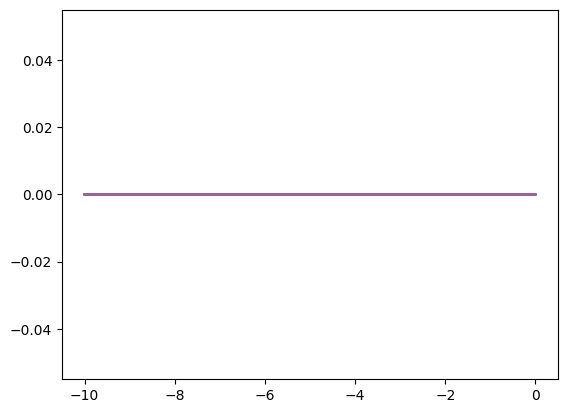

In [493]:
k = np.linspace(-pi,pi,100)

for v in vs:
    y = 0
    for ki in k:
        y += array([ v*(b_k_s(ki, l)) for l in lambdas ])
    plot(lambdas,np.real(y))
    



  0%|          | 0/100 [24:46<?, ?it/s]


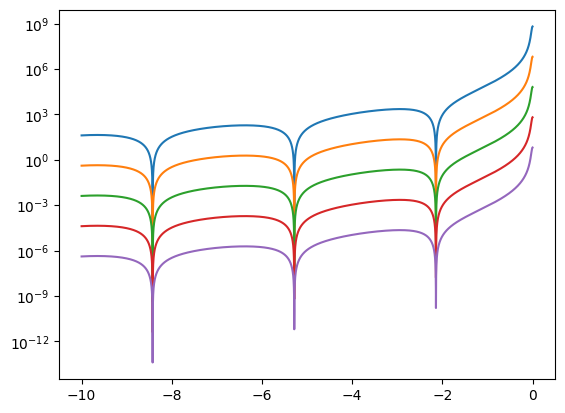

In [497]:
k = np.linspace(-pi,pi,100)

for v in vs:
    y = 0
    for ki in k:
        y += array([ v*(b_k_s(ki, l)) for l in lambdas ])
    plot(lambdas,abs(y)**2)

yscale("log")
    



Text(0.5, 0, '$\\lambda$')

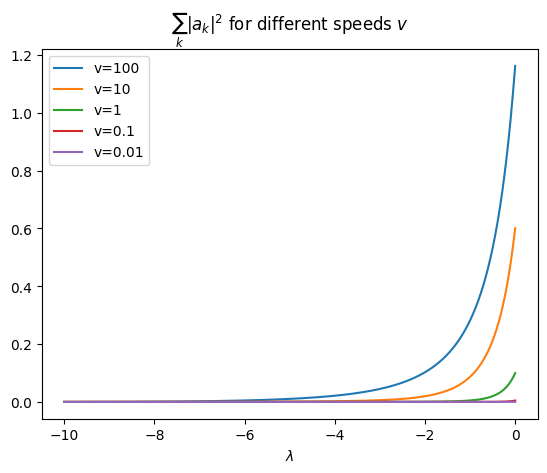

In [475]:
for i, xi in enumerate(x):
    plot(lambdas,xi,label=f"v={vs[i]}")

legend()
title(r"$\sum_k |a_k|^2$ for different speeds $v$")
xlabel(r"$\lambda$")
#yscale("log")



In [457]:
from joblib import Parallel, delayed

l0 = -10
lf = 0.001
N = 1000
taus = np.logspace(-1,2,100)
vs =  1/taus
k = np.linspace(-pi,pi,1000)
lambdas, dl = linspace(l0,lf,N,retstep=True)

def compute_single(v):
    y = sum([ np.abs(b_k(l0,lf,N,ki,v))**2 for ki in k ])
    return y[-1]

x = Parallel(n_jobs=-1)(delayed(compute_single)(v) for v in vs)



/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11105/905809267.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


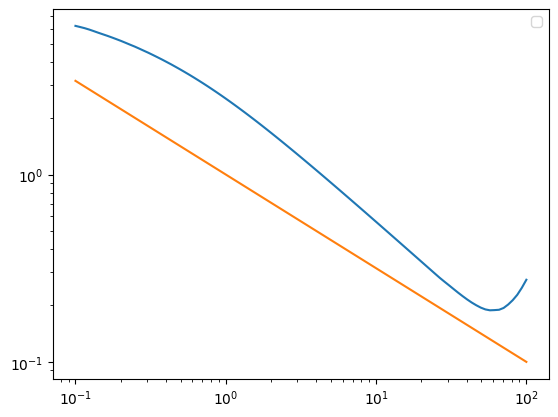

In [458]:
loglog(taus,array(x)**(1/2))
plot(taus,taus**(-1/2))
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11105/2000887600.py:14: RuntimeWarning: divide by zero encountered in log
  return u * np.sqrt(u*u + s*s) + s*s * np.log(u + np.sqrt(u*u + s*s))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11105/2000887600.py:14: RuntimeWarning: invalid value encountered in multiply
  return u * np.sqrt(u*u + s*s) + s*s * np.log(u + np.sqrt(u*u + s*s))


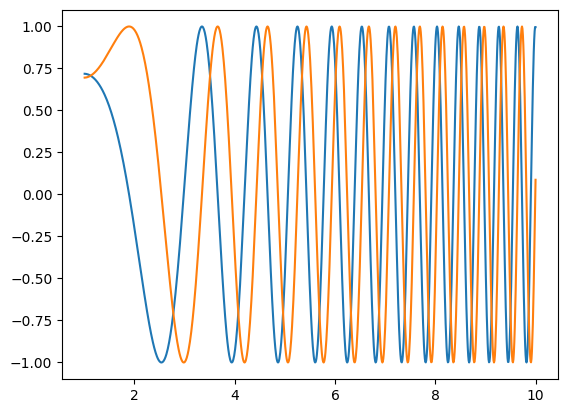

In [330]:
import numpy as np

def phase_integral(k, g, g_star):
    g = np.array(g, dtype=float)

    s = np.sin(k)
    c = np.cos(k)

    # u = g - cos k
    u  = g      - c
    u0 = g_star - c

    def F(u):
        return u * np.sqrt(u*u + s*s) + s*s * np.log(u + np.sqrt(u*u + s*s))

    return F(u) - F(u0)


def phase_factor(k, g, g_star, v):

    S = phase_integral(k, g, g_star)
    return np.exp(1j * S / v)
k = 0
g_star = 100.0
v = 1
g_vals = np.linspace(10, 1, 1000)

phase = phase_factor(k, g_vals, g_star, v)

# real/imag of the oscillatory phase factor
import matplotlib.pyplot as plt
plt.plot(g_vals, np.real(phase))
plt.plot(g_vals, np.imag(phase))
plt.show()


In [331]:
def b_k(k, gs, v, g_star):
    gs = np.array(gs, dtype=float)
    dg = gs[1] - gs[0]

    # analytic phase factor exp[i S_k(g)/v]
    phase = np.array([phase_factor(k, g, g_star, v) for g in gs])

    # P_k(g) = ⟨m|∂g|0⟩  (whatever your z(k,g) is)
    P = np.array([z(k, g) for g in gs])

    # integrand
    integrand = phase * P

    # cumulative integral
    return np.cumsum(integrand * dg)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11105/2000887600.py:14: RuntimeWarning: divide by zero encountered in log
  return u * np.sqrt(u*u + s*s) + s*s * np.log(u + np.sqrt(u*u + s*s))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11105/2000887600.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  return u * np.sqrt(u*u + s*s) + s*s * np.log(u + np.sqrt(u*u + s*s))


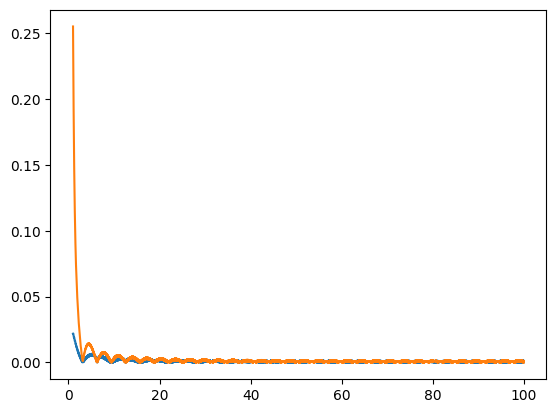

In [332]:
g_star = 100
gs = np.linspace(100, 1, 50000)
v = 0.1

bk = b_k(k=pi/2, gs=gs, v=v, g_star=g_star)

plot(gs, np.abs(bk))
bk = b_k(k=0, gs=gs, v=v, g_star=g_star)

plot(gs, np.abs(bk))

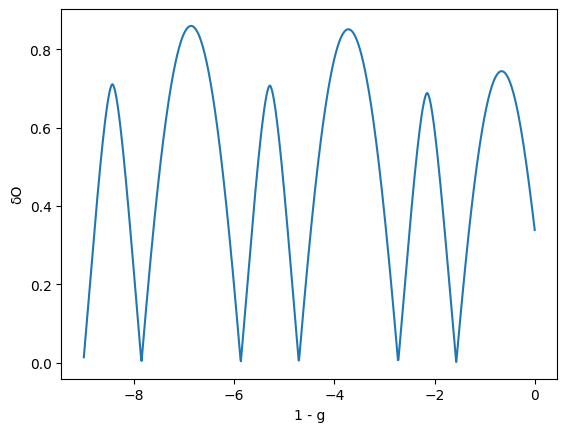

In [329]:
import numpy as np
from joblib import Parallel, delayed

def delta_O_xx(g_vals, k_vals, v, g_star, n_jobs=-1):

    dk = k_vals[1] - k_vals[0]

    def contrib(ki):
        # analytic b_k(g) using the new formula
        bk = b_k(ki, g_vals, v, g_star)

        # <0|σ_x σ_{x+1}|k,-k> for each g
        xx_vals = np.array([xx(ki, gi) for gi in g_vals])

        # return integrand contribution for this k
        return 2 * np.real(bk * xx_vals) * dk

    # parallel evaluation over all k
    parts = Parallel(n_jobs=n_jobs)(
        delayed(contrib)(ki) for ki in k_vals
    )

    # sum over k contributions
    return np.sum(parts, axis=0)
k_vals = np.linspace(-np.pi, np.pi, 200)
g_vals = np.linspace(10, 1, 1000)

v = 1000
g_star = g_vals[0]      # 100

X = delta_O_xx(g_vals, k_vals, v, g_star, n_jobs=-1)

import matplotlib.pyplot as plt
plt.plot(1 - g_vals, abs(X))
plt.xlabel("1 - g")
plt.ylabel("δO")
plt.show()


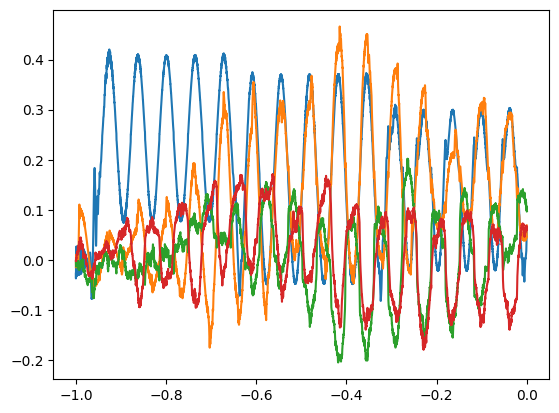

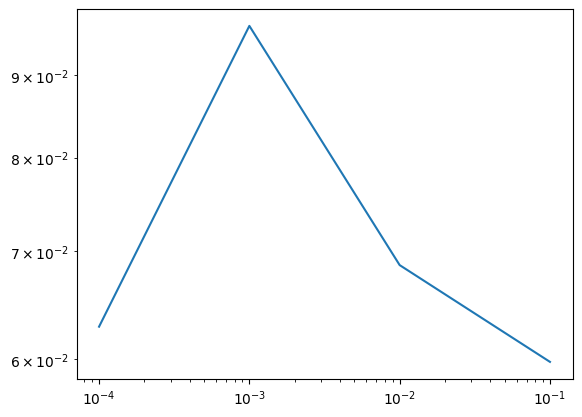

In [228]:
vs = [1/10,1/100,1/1000,1/10000]
dat = []
for v in vs:
    X = delta_O_xx(g_vals, k_vals, v)
    plot(1-g,X)
    dat.append(X[-1])
show(
)

loglog(vs,dat)

##  boo

In [248]:
import numpy as np
from scipy.special import exp1     # E1(z) = integral_z^∞ e^{-t}/t dt

def b_k_exact(k, g, g_i, v):
    """
    Exact analytic APT excitation amplitude b_k(g)
    for TFIM quench g_i → g, using exponential integral E1.

    k   : momentum
    g   : final g-value (can be array)
    g_i : initial g (>1)
    v   : quench rate
    """
    # allow vectorized g
    g = np.array(g, dtype=np.float64)

    # Definitions
    s = np.sin(k)
    c = np.cos(k)

    # u = g - cos k
    u  = g  - c
    u_i = g_i - c

    # helper functions
    def F(u):
        # u * sqrt(u^2 + s^2)
        return u * np.sqrt(u*u + s*s)

    def G(u):
        # u + sqrt(u^2 + s^2)
        return u + np.sqrt(u*u + s*s)

    # Constant C_k from initial point
    Ck = F(u_i) + s*s * np.log(G(u_i))

    # arguments of E1
    A  = (F(u)  + s*s * np.log(G(u) )) / v * 1j
    A0 = (F(u_i) + s*s * np.log(G(u_i))) / v * 1j

    # exact formula
    prefactor = -0.5j / s * np.exp(-1j * Ck / v)

    return prefactor * (exp1(A) - exp1(A0))


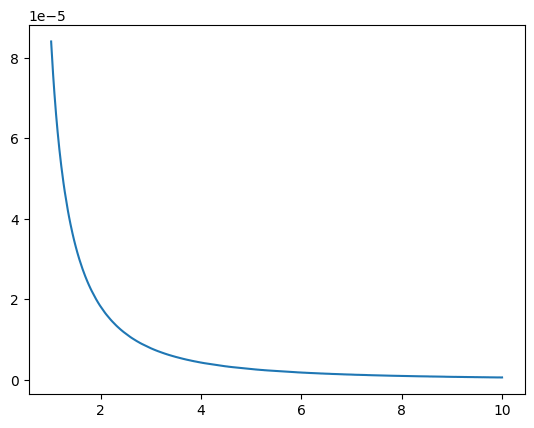

In [283]:
k = 1
g_i = 100
v = 0.0001
g_vals = np.linspace(10, 1.01, 5000)

b_exact = b_k_exact(k, g_vals, g_i, v)
plot(g_vals, np.abs(b_exact))


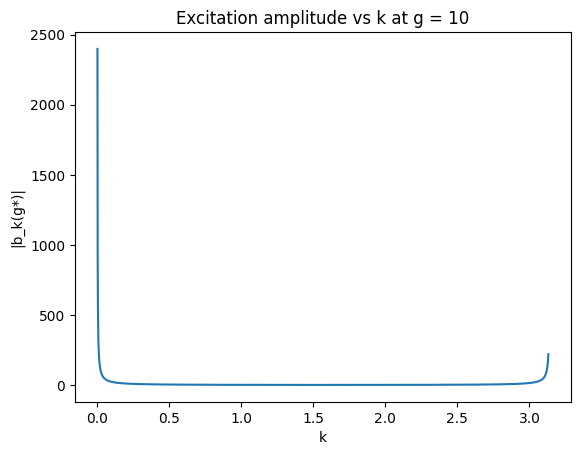

In [279]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
g_i = 100
v   = 10000000

# choose the specific g you want to evaluate at
g_star = 10  # for example

# build a momentum grid
k_vals = np.linspace(0.001, np.pi-0.01, 2000)

# compute b_k(g_star) for every k
b_vals = np.array([b_k_exact(k, g_star, g_i, v) for k in k_vals])

# plot
plt.plot(k_vals, np.abs(b_vals))
plt.xlabel("k")
plt.ylabel("|b_k(g*)|")
plt.title(f"Excitation amplitude vs k at g = {g_star}")
plt.show()


Text(0, 0.5, 'δO')

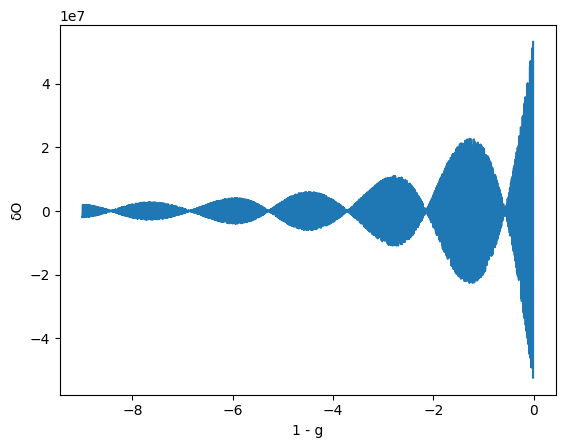

In [ ]:
def delta_O_xx_exact(g_vals, k_vals, g_i, v):
    dg = g_vals[1] - g_vals[0]
    dk = k_vals[1] - k_vals[0]

    X = np.zeros(len(g_vals), dtype=float)

    for ki in k_vals:
        # analytic b_k(g)
        bk = b_k_exact(ki, g_vals, g_i, v)     # array over g

        # <0|σ_x σ_{x+1}|k,-k>
        xx_vals = np.array([xx(ki, gi) for gi in g_vals])

        # accumulate 2 Re[ b_k xx ] * dk
        X += 2 * np.real(bk * xx_vals) * dk

    return X
g_vals = np.linspace(10, 1.01, 5000)
k_vals = np.linspace(-np.pi, np.pi, 2000)
g_i = 100
v   = 0.0001

X = delta_O_xx_exact(g_vals, k_vals, g_i, v)

plot(1 - g_vals, abs(X))
xlabel("1 - g")
ylabel("δO")


Text(0, 0.5, 'δO')

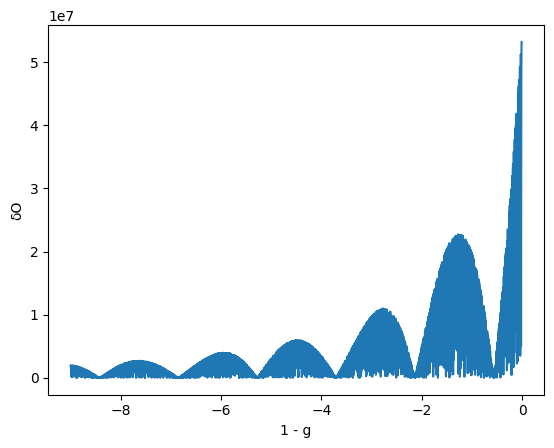

In [285]:
plot(1 - g_vals, abs(X))
xlabel("1 - g")
ylabel("δO")

In [69]:
import kblock_ising_model as kb
import kibble_zurek as kz 

In [6]:
###Get the equilibrium hamiltonians at each g 
L = 1000
def g_t(t,tau):
    return 1-t/tau
k = np.linspace(-pi,pi,L)
tau =100
v= 1/tau
t = np.linspace(-tau,0,100)

gs = g_t(t,tau)

agp = array([delta_O(k,g,v) for g in gs])

In [7]:


x = []
for g in tqdm(gs):
    k_vals = kb.k_vals(L)

    U = kb.U(k_vals,g)
    x.append(kb.sigma_general([0,1],U,k_vals))

x= array(x)

###Get the exact time dpeendent project at each g(t)
y = []
for ti in tqdm(t):
    state= kz.state(L,tau,ti)
    y.append(kz.sigma_general([0,1],state))

y= array(y)

100%|██████████| 100/100 [02:23<00:00,  1.43s/it]


[]

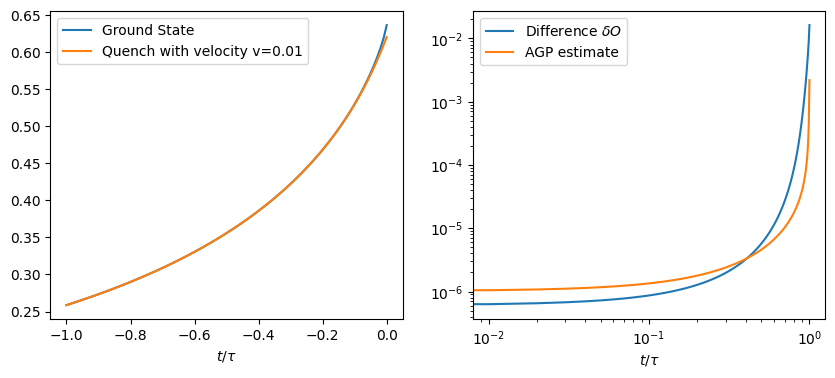

In [17]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(t/tau,x,label="Ground State")
ax[0].plot(t/tau,y,label= f"Quench with velocity v={v}")
ax[0].legend()
ax[0].set_xlabel(r"$t/\tau$")


ax[1].plot(t/tau+1,x-y,label=r"Difference $\delta O$")
ax[1].plot(t/tau+1,-agp/L/2/pi/2/32,label=r"AGP estimate")
ax[1].set_xlabel(r"$t/\tau$")
ax[1].legend()
ax[1].loglog()

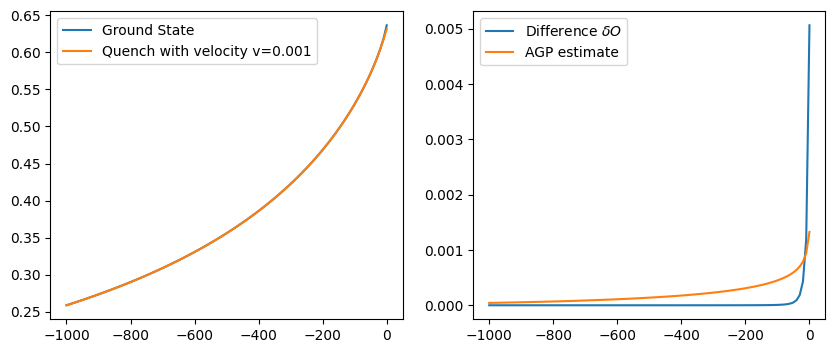

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(t,x,label="Ground State")
ax[0].plot(t,y,label= f"Quench with velocity v={v}")
ax[0].legend()

ax[1].plot(t,x-y,label=r"Difference $\delta O$")
ax[1].plot(t,-agp/L/2/pi/,label=r"AGP estimate")
ax[1].legend()

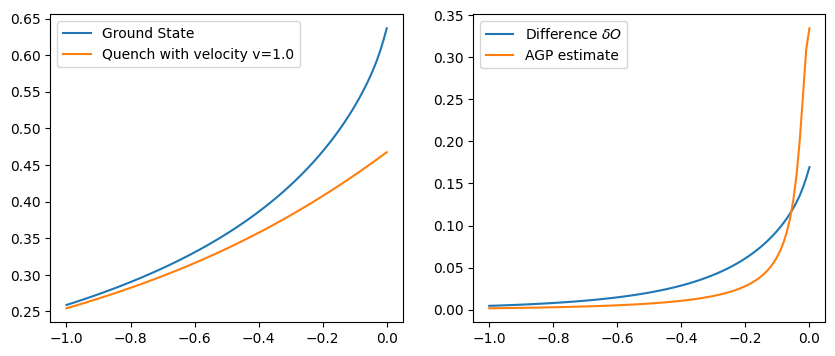

In [86]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(t,x,label="Ground State")
ax[0].plot(t,y,label= f"Quench with velocity v={v}")
ax[0].legend()

ax[1].plot(t,x-y,label=r"Difference $\delta O$")
ax[1].plot(t,-agp/L/2/pi/2/2,label=r"AGP estimate")
ax[1].legend()